In [1]:
import torch
from torch import nn, optim
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from wgan.wgan import WGAN
from wgan.resblock import GeneratorResBlock, CriticResBlock
from wgan.utils import APA
from ada import AdaptiveDiscriminatorAugmentation
from wgan.train import train_wgan

In [2]:
image_size = 128

t_normalize = lambda x : x * 2 - 1
t_invnormalize = lambda x : x * 0.5 + 0.5

train_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    t_normalize,
])

test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    t_normalize,
])

In [3]:
train_set = ImageFolder(root = './example_skin_cancer/train', transform = train_transform)
test_set = ImageFolder(root = './example_skin_cancer/test', transform = test_transform)

train_loader = DataLoader(train_set, batch_size = 8, shuffle = True, pin_memory = False)
test_loader = DataLoader(test_set, batch_size = 8, shuffle = False, pin_memory = False)

In [4]:
def show_images(images, nrow = 1):
    plt.figure(figsize = (20, 20))
    plt.imshow(make_grid(t_invnormalize(images.detach().cpu()), nrow = nrow).permute(1, 2, 0))
    plt.axis('off')

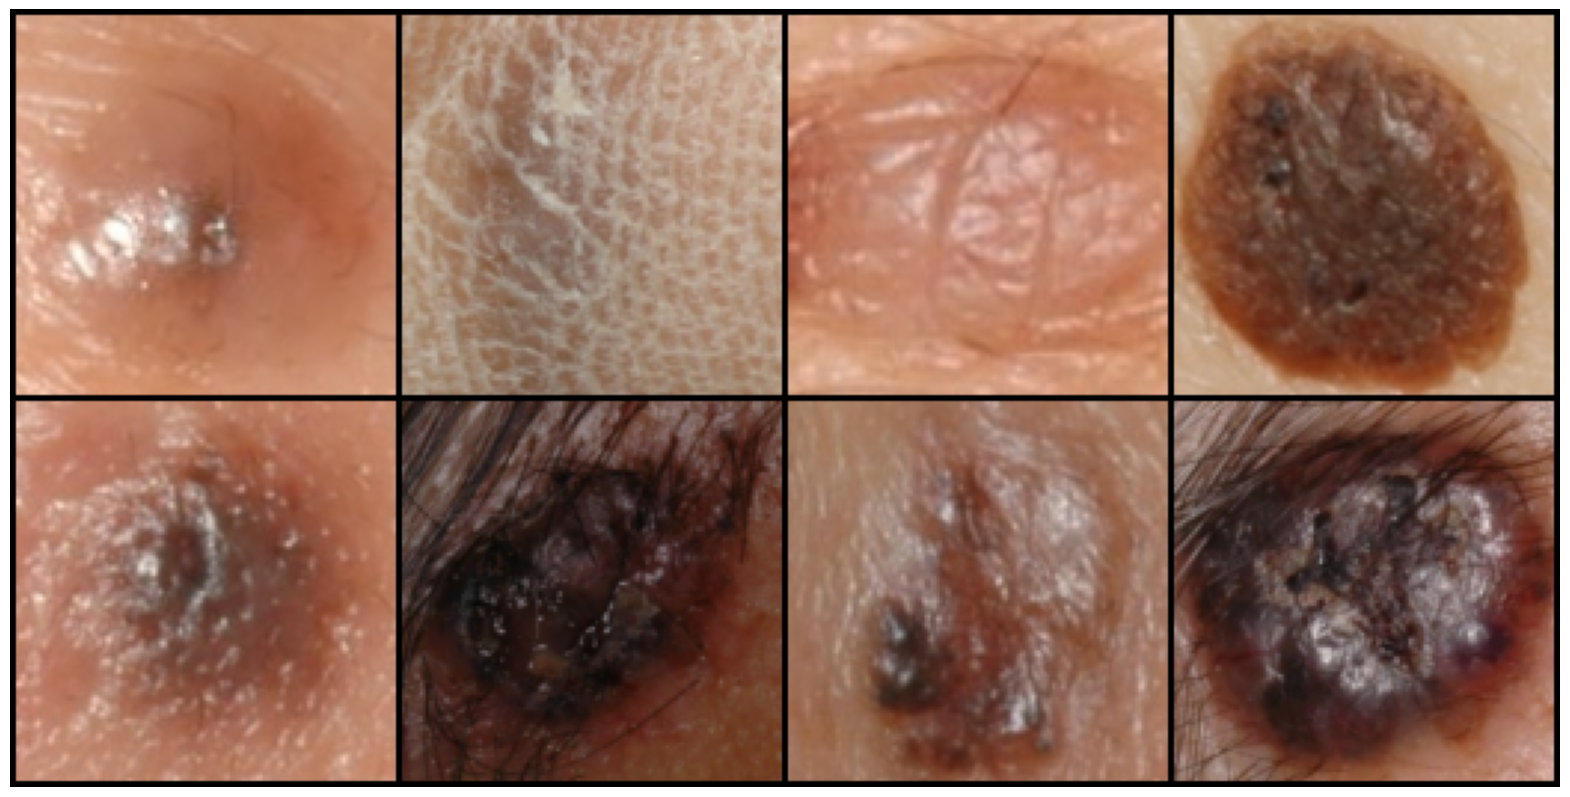

In [5]:
x, c = train_loader.__iter__().__next__()
show_images(x, 4)

In [6]:
apa = APA()
apa.set_p(0.0)

In [7]:
class GeneratorBackbone(nn.Module): # Generates features from random latent for the generator
    def __init__(self):
        super().__init__()
        
        self.in_shape = (128,)
        self.out_shape = (128, 128, 128)

        self.linear = nn.Linear(128, 128 * 4 * 4)
        self.gs = nn.ModuleList([GeneratorResBlock(128, 128, 2, upsample = True) for i in range(5)])

    def forward(self, z, c):
        x = self.linear(z).view(-1, 128, 4, 4)
        for g in self.gs:
            x = g(x, c)
        return x
        
class CriticBackbone(nn.Module): # Extracts features for the critic
    def __init__(self):
        super().__init__()

        self.in_shape = (3, 128, 128)
        self.out_shape = (128,)

        self.skip = nn.Sequential(
            nn.Conv2d(3, 32, 1, 1, 0),
            nn.AvgPool2d(kernel_size = 2)
        )
        self.conv1 = nn.Conv2d(3, 32, 3, 1, 1)
        self.act = nn.ReLU()
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 32, 3, 1, 1),
            nn.AvgPool2d(kernel_size = 2)
        )

        self.gs = nn.Sequential(
            CriticResBlock(32, 64, (64, 64), downsample = True),
            CriticResBlock(64, 128, (32, 32), downsample = True),
            CriticResBlock(128, 128, (16, 16), downsample = True),
            CriticResBlock(128, 128, (8, 8), downsample = False),
            CriticResBlock(128, 128, (8, 8), downsample = False),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size = 8),
            nn.Flatten()
        )

    def forward(self, x):
        s = self.skip(x)
        x = self.conv1(x)
        x = self.act(x)
        x = self.conv2(x)
        x = x + s

        features = self.gs(x)
        return features

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [9]:
generator_backbone = GeneratorBackbone()
critic_backbone = CriticBackbone()

In [10]:
wgan = WGAN(
    wgan_type = 'pc',
    num_classes = 2,
    generator_backbone = generator_backbone,
    critic_backbone = critic_backbone,
    aug = apa,
    device = device
)

In [11]:
loss_logs = [[], [], [], [], []]
fid_logs = []
optimizers = {}
optimizers['crt'] = optim.AdamW(wgan.critic.parameters(), lr = 2e-4, weight_decay = 1e-3, betas = (0.0, 0.9))
optimizers['gen'] = optim.AdamW(wgan.generator.parameters(), lr = 2e-4, weight_decay = 1e-3, betas = (0.0, 0.9))
schedulers = {}
schedulers['crt'] = optim.lr_scheduler.LinearLR(optimizers['crt'], start_factor = 1, end_factor = 0.0, total_iters = 10 ** 5)
schedulers['gen'] = optim.lr_scheduler.LinearLR(optimizers['gen'], start_factor = 1, end_factor = 0.0, total_iters = 10 ** 5)
n_iters = 10 ** 5
show_every = 25
disc_iters = 5
save_every = 5000

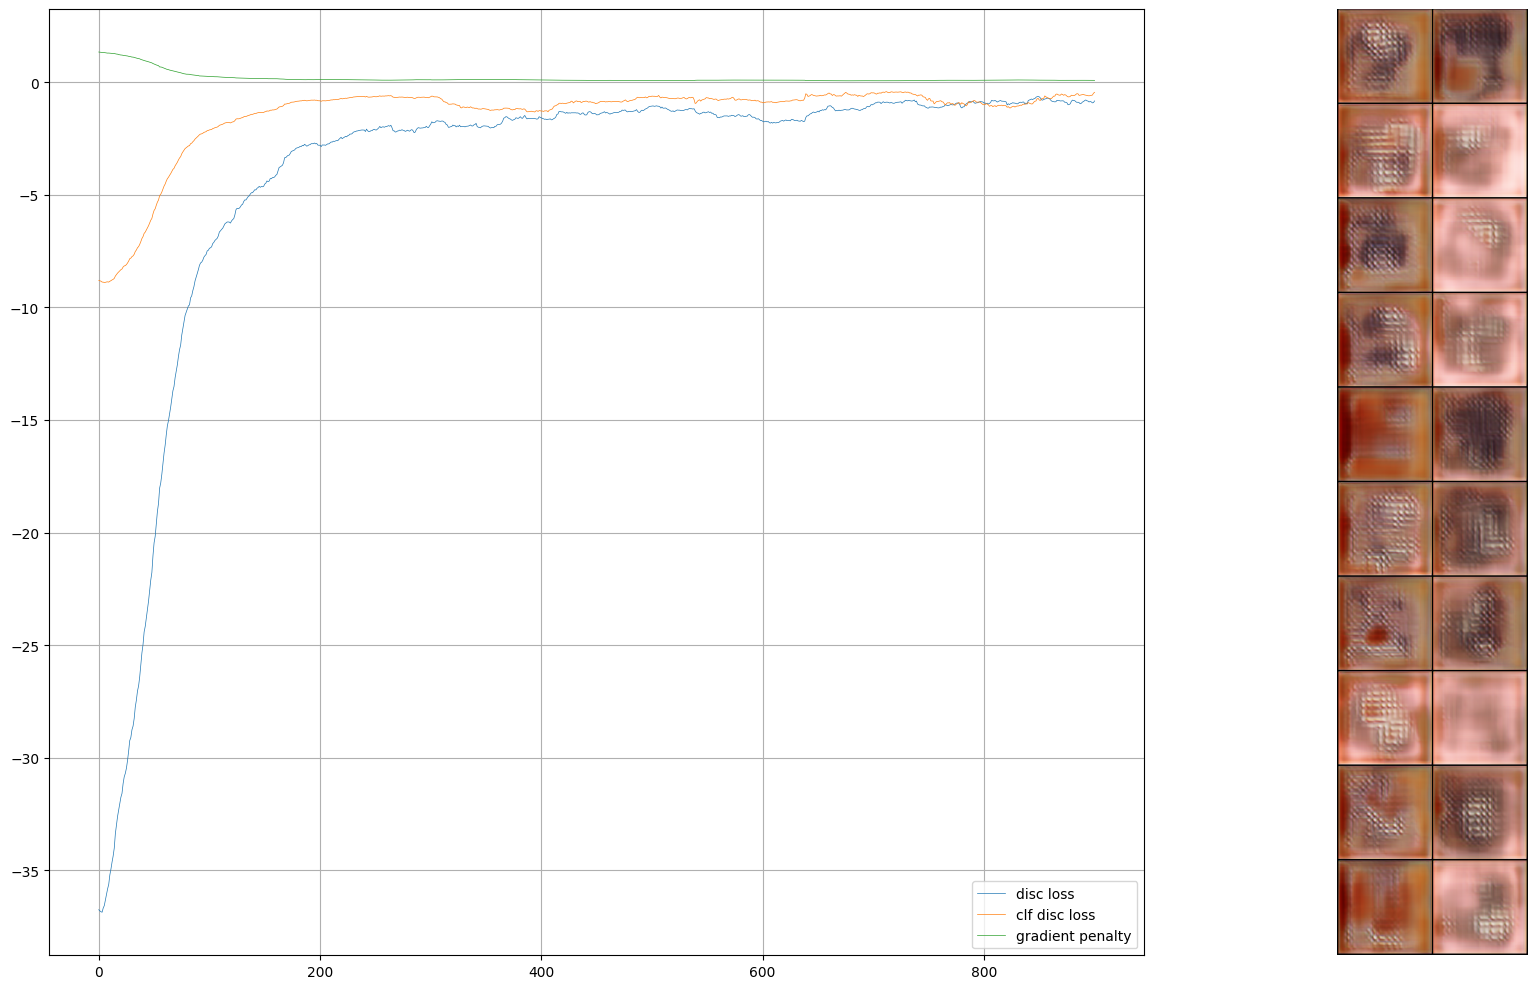


%|                                                                                            | 0/2 [00:00<?, ?it/s]
100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.71s/it]

%|                                                                                            | 0/4 [00:00<?, ?it/s]
%|█████████████████████                                                               | 1/4 [00:02<00:07,  2.67s/it]
%|██████████████████████████████████████████                                          | 2/4 [00:02<00:02,  1.16s/it]
disc/clf/p: 1.03017/14.20245/0.420000: 100%|███████████████████████████████████████| 1000/1000 [12:56<00:00,  1.29it/s]


In [12]:
train_wgan(
    wgan,
    optimizers,
    schedulers,
    train_loader,
    loss_logs,
    fid_logs,
    save_path = './example_skin_cancer',
    test_path = './example_skin_cancer_test',
    sample_count = 100,
    aug_f = lambda x: 4.5 * x + 0.1,
    n_iters = 1000,
    disc_iters = 5,
    show_every = 5,
    save_every = 100,
)